In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target/species column
df['species'] = iris.target

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [2]:
# Check the dataset information
df.info()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check the shape of the dataset
print("\nDataset shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Dataset shape: (150, 5)


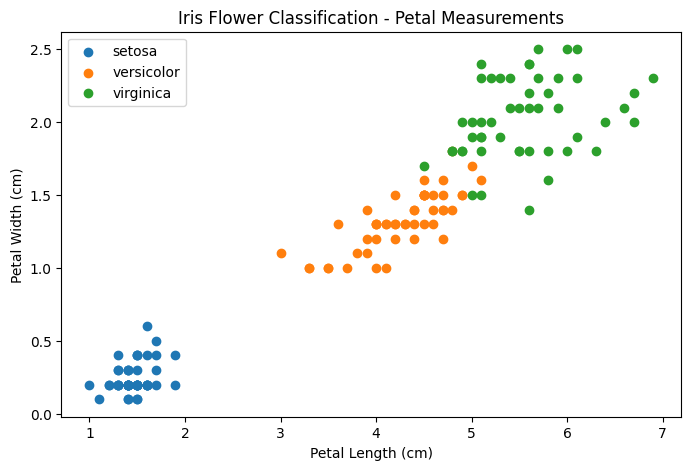

In [3]:
# Visualize the relationship between petal length and petal width

plt.figure(figsize=(8, 5))

for species in sorted(df['species'].unique()):
    data = df[df['species'] == species]
    plt.scatter(
        data['petal length (cm)'],
        data['petal width (cm)'],
        label=iris.target_names[species]
    )

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Flower Classification - Petal Measurements')
plt.legend()
plt.show()

In [5]:
# Prepare the data

X = iris.data
y = iris.target

# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 120
Testing samples: 30


In [6]:
# Train the machine learning model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [7]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [8]:
# Evaluate the model accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.9666666666666667
Model Accuracy (%): 96.66666666666667


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



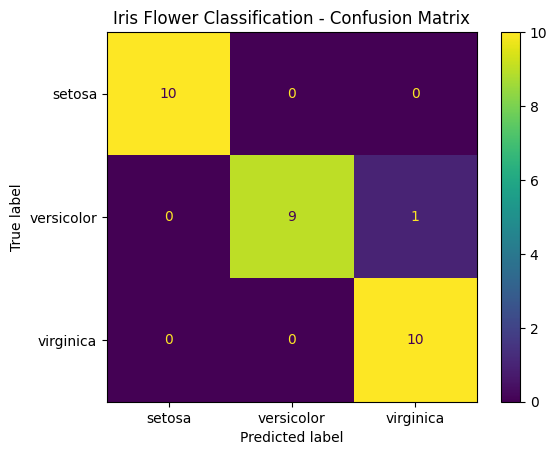

In [9]:
# Confusion Matrix and Classification Report

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Iris Flower Classification - Confusion Matrix")
plt.show()

In [10]:
# Predict the species of a new Iris flower

new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted species:", iris.target_names[prediction[0]])

Predicted species: setosa


Conclusion

In this project, an Iris Flower Classification model was developed using Python and Scikit-learn. The Iris dataset was explored and visualized, then divided into training and testing data. A Logistic Regression model was trained to classify Iris flowers into Setosa, Versicolor, and Virginica. The model was evaluated using accuracy, a confusion matrix, and a classification report. The trained model was also tested with a new flower sample and successfully predicted its species as Setosa.

This project demonstrates the basic workflow of a machine learning classification problem, from data preparation and visualization to model training, prediction, and evaluation.